# EDA — DropSeq datasets

DropSeq is a **droplet-based** scRNA-seq protocol: each cell is encapsulated
in a microfluidic droplet, lysed, and tagged with a cell-specific barcode +
UMI. Trade-off vs SmartSeq:

| | SmartSeq | DropSeq |
|---|---|---|
| cells per experiment | ~10²–10³ | 10³–10⁵ |
| reads per cell | many (full-length) | few (3' end only) |
| sparsity | moderate | very high (lots of zeros) |
| sensitivity | high | lower (loses lowly-expressed genes) |

Here we only have the **Filtered+Normalised 3000-HVG** flavour for DropSeq
(no raw counts). Labels are embedded in the column names —
`AAAACGAGCTAG_Normoxia` / `AAAAAACCCGGC_Hypoxia` — our loader strips and
normalises them to `Norm` / `Hypo`.

In [1]:
import sys
from pathlib import Path

# put the project root on sys.path (notebook 04 imports helpers from src/)
sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
RNG = 42

In [2]:
from src.utils import load_smartseq, load_dropseq

In [ ]:
CELL_LINES = ["MCF7", "HCC1806"]

## 1 — Shape and label balance

In [ ]:
summary = []
Xs, ys = {}, {}
for cl in CELL_LINES:
    X, y = load_dropseq(cl, split="train")
    Xs[cl], ys[cl] = X, y
    counts = y.value_counts().to_dict()
    summary.append({"cell_line": cl, "n_cells": X.shape[0], "n_genes": X.shape[1], **counts})
pd.DataFrame(summary).set_index("cell_line")

,n_cells,n_genes,Norm,Hypo
cell_line,,,,
MCF7,21626,3000,12705,8921
HCC1806,14682,3000,5783,8899


DropSeq gives us **~15–20k cells per cell line** — two orders of magnitude
more than SmartSeq. Labels are slightly unbalanced (more Norm than Hypo)
but still very usable for classification without resampling.

## 2 — Sparsity

In [ ]:
for cl, X in Xs.items():
    zeros = (X.values == 0).mean() * 100
    mean_genes_per_cell = (X.values > 0).sum(axis=1).mean()
    mean_cells_per_gene = (X.values > 0).sum(axis=0).mean()
    print(
        f"{cl:8s} %zeros = {zeros:.1f}%  | avg expressed genes / cell = {mean_genes_per_cell:.0f}  "
        f"| avg cells / gene = {mean_cells_per_gene:.0f}"
    )

MCF7     %zeros = 97.5%  | avg expressed genes / cell = 74  | avg cells / gene = 534
HCC1806  %zeros = 97.6%  | avg expressed genes / cell = 71  | avg cells / gene = 347


Even after HVG selection, DropSeq matrices are **>70% zero** — the canonical
"dropout" effect of droplet protocols. Classifiers should be robust to this
(linear models with L2/L1, tree ensembles).

## 3 — Per-cell library size distribution

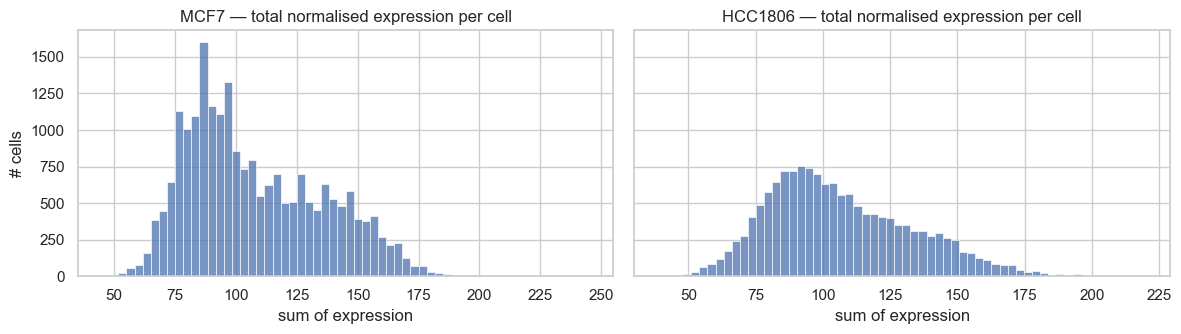

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, (cl, X) in zip(axes, Xs.items()):
    lib = X.sum(axis=1)
    sns.histplot(lib, ax=ax, bins=60)
    ax.set_title(f"{cl} — total normalised expression per cell")
    ax.set_xlabel("sum of expression")
    ax.set_ylabel("# cells")
plt.tight_layout()
plt.show()

## 4 — Top variable genes by condition

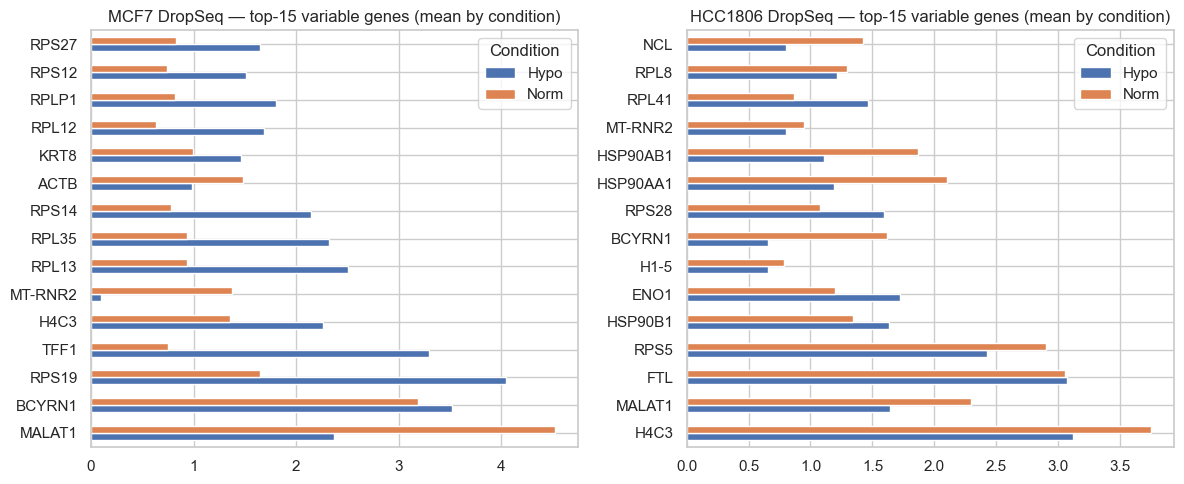

In [ ]:
# For each cell line, look at how the top variable genes differ between Hypo and Norm.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cl in zip(axes, CELL_LINES):
    X, y = Xs[cl], ys[cl]
    top = X.var(axis=0).sort_values(ascending=False).head(15).index
    (X[top].groupby(y).mean().T.plot.barh(ax=ax, title=f"{cl} DropSeq — top-15 variable genes (mean by condition)"))
plt.tight_layout()
plt.show()

## 5 — Are canonical hypoxia markers retained as HVGs?

In [ ]:
# The teacher's 3000-gene matrices keep only the top highly-variable genes.
# Do the *known* hypoxia markers survive that selection on DropSeq?
MARKERS = ["VEGFA", "CA9", "SLC2A1", "LDHA", "BNIP3", "HK2", "PGK1", "NDRG1", "HILPDA", "P4HA1", "EGLN3"]
for cl, X in Xs.items():
    present = [m for m in MARKERS if m in X.columns]
    print(f"{cl}: {len(present)}/{len(MARKERS)} canonical markers kept -> {present}")

MCF7: 1/11 canonical markers kept -> ['PGK1']
HCC1806: 10/11 canonical markers kept -> ['CA9', 'SLC2A1', 'LDHA', 'BNIP3', 'HK2', 'PGK1', 'NDRG1', 'HILPDA', 'P4HA1', 'EGLN3']


A striking cross-dataset contrast: **HCC1806 DropSeq keeps most canonical HIF
targets** among its top-3000 HVGs, while **MCF7 DropSeq keeps almost none** —
its highly-variable axis is dominated by other programmes (e.g. cell cycle).
This is a direct consequence of HVG selection on a sparse, dropout-heavy matrix,
and it foreshadows a **weaker label-aligned structure for MCF7 DropSeq** in the
unsupervised analysis (notebook 02) and possibly a harder classification task
(notebook 03). It is a good concrete example of how preprocessing choices made
*before* we ever see the data shape what a model can learn.

## 6 — A glance at the test sets

In [ ]:
# Test files have anonymised cell IDs (just integers) — we cannot recover labels.
# Confirm the gene-set is the same.
for cl in CELL_LINES:
    X_te, y_te = load_dropseq(cl, split="test")
    assert y_te is None
    same_genes = (X_te.columns == Xs[cl].columns).all()
    print(f"{cl}: test set shape = {X_te.shape}  same-genes-as-train = {same_genes}")

MCF7: test set shape = (5406, 3000)  same-genes-as-train = True


HCC1806: test set shape = (3671, 3000)  same-genes-as-train = True


## 7 — DropSeq vs SmartSeq — quick contrast

- **Cells:** DropSeq has ~80–100× more cells. SmartSeq has fewer but
  higher-quality cells.
- **Sparsity:** DropSeq is dominated by dropouts. SmartSeq is denser.
- **Implication for ML:** DropSeq is great for unsupervised structure
  discovery (more samples) but classifier comparison is more robust on
  balanced, dense matrices like SmartSeq.
- **Implication for the report:** Train one model per (cell_line × tech)
  dataset and compare — that's what notebook 03 does.